In [ ]:
import itertools, csv, time
from pathlib import Path
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Results

In [ ]:
RESULTS_CSV = "clean_grid_search_results.csv"

# 1. Load the data
df = pd.read_csv(RESULTS_CSV)
df_ok = df[df["status"] == "ok"].copy()

print(f"Total runs: {len(df)}  |  Successful: {len(df_ok)}  |  Failed: {len(df) - len(df_ok)}")

# 2. Define Baseline Constants
# These match the BASELINE dict from your original grid search code
BASELINE_PARAMS = {
    "epochs": 100,
    "batch": 16,
    "lr0": 0.01,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "mosaic": 1.0
}

# 3. Fix the Baseline Row
# Identify rows where run_name contains 'baseline'
mask_baseline = df_ok['run_name'].str.contains('baseline', case=False, na=False)

if mask_baseline.any():
    print("✅ Baseline row detected. Filling hyperparameters...")
    
    # Fill the specific columns for the baseline row only
    for col, val in BASELINE_PARAMS.items():
        if col in df_ok.columns:
            df_ok.loc[mask_baseline, col] = val
            
    # Ensure 'run_type' is correctly labeled
    df_ok.loc[mask_baseline, 'run_type'] = 'baseline'
else:
    print("⚠️ Warning: No baseline row found in the CSV.")

# 4. Ensure correct data types for sorting/plotting
# (Sometimes CSV reading interprets numbers as objects if mixed with strings)
numeric_cols = ['epochs', 'batch', 'lr0', 'hsv_s', 'hsv_v', 'mosaic', 
                'seg_map50_95', 'seg_map50', 'box_map50_95']
for col in numeric_cols:
    if col in df_ok.columns:
        df_ok[col] = pd.to_numeric(df_ok[col], errors='coerce')

# 5. Display the sorted table
# Sort by segmentation mAP50-95 (your primary metric)
display_df = df_ok.sort_values(by="seg_map50_95", ascending=False).reset_index(drop=True)

# Optional: Reorder columns for better readability
cols_order = [
    "run_name", "run_type", "seg_map50_95", "seg_map50", 
    "box_map50_95", "box_map50", 
    "epochs", "batch", "lr0", "hsv_s", "hsv_v", "mosaic", 
    "inference_ms", "status"
]
# Only keep columns that exist in the dataframe
final_cols = [c for c in cols_order if c in display_df.columns]

display(display_df[final_cols])

Total runs: 26  |  Successful: 26  |  Failed: 0
✅ Baseline row detected. Filling hyperparameters...


,run_name,run_type,seg_map50_95,seg_map50,box_map50_95,box_map50,epochs,batch,lr0,hsv_s,hsv_v,mosaic,inference_ms,status
0,baseline,baseline,0.5694,0.8527,0.6361,0.8398,100.0,16.0,0.010,0.70,0.4,1.0,1.38,ok
1,ep50_bs8_lr0p001_s0_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.001,0.00,0.2,1.0,3.06,ok
2,ep50_bs8_lr0p001_s0p35_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.001,0.35,0.2,1.0,0.65,ok
3,ep50_bs8_lr0p01_s0p7_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.010,0.70,0.2,1.0,0.65,ok
4,ep50_bs8_lr0p01_s0_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.010,0.00,0.2,1.0,0.66,ok
5,ep50_bs8_lr0p001_s0p7_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.001,0.70,0.2,1.0,0.66,ok
6,ep50_bs8_lr0p01_s0p35_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.010,0.35,0.2,1.0,0.66,ok
7,ep50_bs8_lr0p001_s0_v0p2_mos0p5,grid,0.5394,0.7959,0.5838,0.7917,50.0,8.0,0.001,0.00,0.2,0.5,0.65,ok
8,ep50_bs8_lr0p001_s0p7_v0p2_mos0p5,grid,0.5394,0.7959,0.5838,0.7917,50.0,8.0,0.001,0.70,0.2,0.5,0.68,ok
9,ep50_bs8_lr0p001_s0p35_v0p2_mos0p5,grid,0.5394,0.7959,0.5838,0.7917,50.0,8.0,0.001,0.35,0.2,0.5,0.66,ok


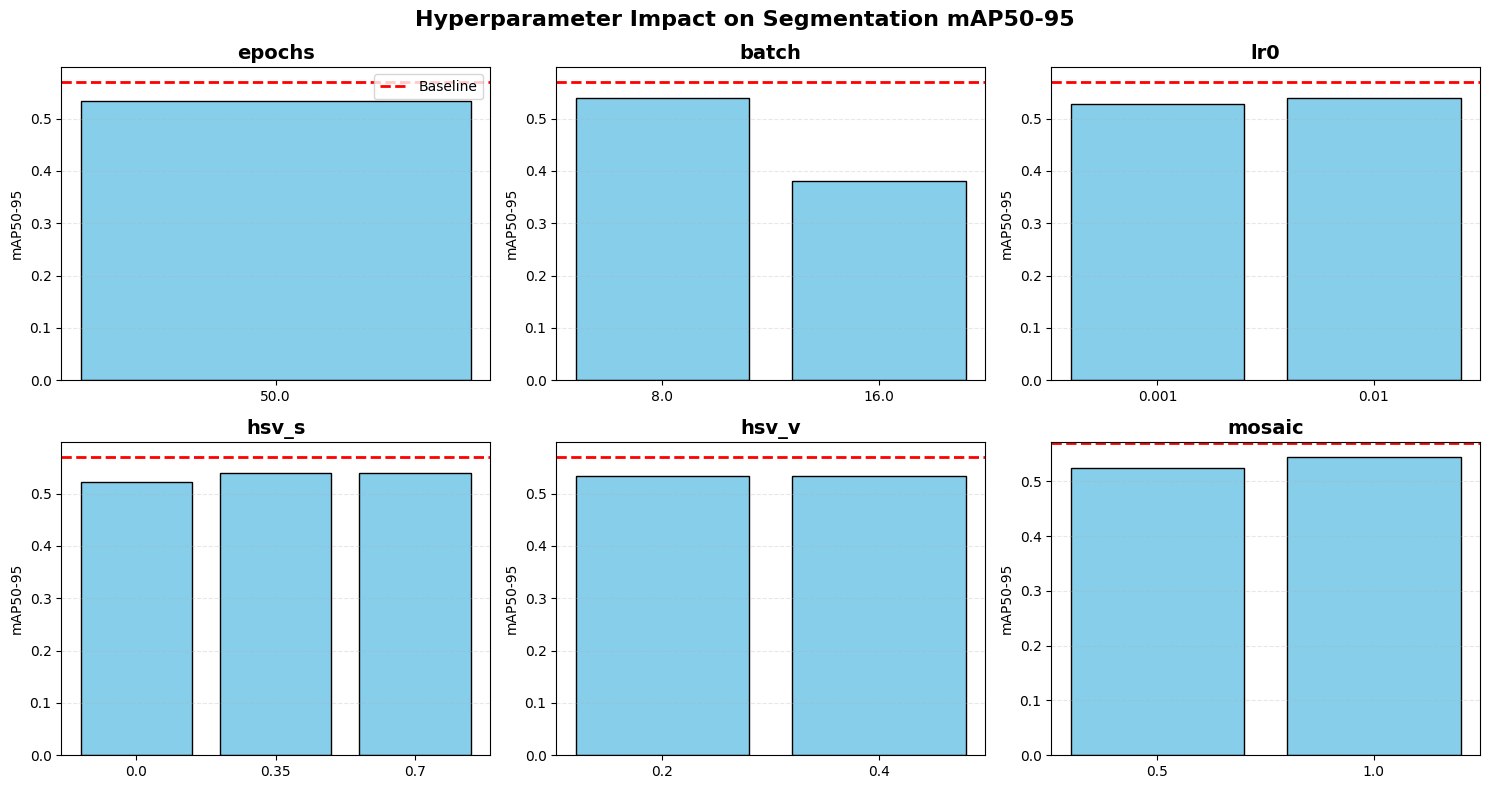

In [6]:
import matplotlib.pyplot as plt

params_to_plot = ["epochs", "batch", "lr0", "hsv_s", "hsv_v", "mosaic"]
grid_df = df_ok[df_ok["run_type"] == "grid"]

# Get baseline value
baseline_val = df_ok[df_ok["run_type"] == "baseline"]["seg_map50_95"].iloc[0] if len(df_ok[df_ok["run_type"] == "baseline"]) > 0 else None

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, param in enumerate(params_to_plot):
    # Calculate mean performance for each value of the parameter
    stats = grid_df.groupby(param)["seg_map50_95"].mean().sort_index()
    
    # Simple bar plot
    axes[i].bar(stats.index.astype(str), stats.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f"{param}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("mAP50-95")
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add baseline line
    if baseline_val is not None:
        axes[i].axhline(baseline_val, color='red', linestyle='--', linewidth=2, label='Baseline')
        if i == 0: # Show legend only once
            axes[i].legend()

plt.suptitle("Hyperparameter Impact on Segmentation mAP50-95", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()